### a. [LO2 – 5 Points] Lakukan Exploratory Data Analysis (EDA) untuk memahami dan mengidentifikasi masalah pada dataset anda. Lakukan pre-processing pada dataset anda sesuai dengan hasil EDA anda, termasuk memisahkan dataset anda menjadi train, val, dan test dengan proporsi 70:10:20.

# SIMPLE EDA

In [ ]:
import numpy as np
import pandas as pd
import random

SEED_VALUE=123
random.seed(SEED_VALUE)
np.random.seed(SEED_VALUE)

df = pd.read_parquet('1B.parquet')
df.head()

,Sales_ID,name,year,selling_price,km_driven,Region,State or Province,City,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,sold
0,1933,Maruti,2013,4500.00,41800,South,Florida,Orlando,Petrol,Individual,Manual,First_Owner,18.6,1197,85.8,114Nm@ 4000rpm,5,Y
1,4901,Ford,2004,4000.00,93415,East,Massachusetts,Abington,Diesel,Dealer,Manual,First_Owner,13.1,2499,141.0,330Nm@ 1800rpm,7,N
2,2802,Honda,2017,8199.99,12000,South,Arkansas,Benton,Petrol,Individual,Manual,First_Owner,17.5,1199,88.7,110Nm@ 4800rpm,5,N
3,7949,Maruti,2016,6750.00,108000,East,New York,East Massapequa,Diesel,Dealer,Manual,First_Owner,23.65,1248,88.5,200Nm@ 1750rpm,5,N
4,966,Maruti,2019,6750.00,5000,Central,Illinois,Chicago,Petrol,Individual,Automatic,First_Owner,21.4,1197,83.1,115Nm@ 4000rpm,5,Y


In [ ]:
df.describe()

,Sales_ID,year,selling_price,km_driven,engine,max_power,seats
count,2000.000000,2000.000000,1998.000000,2000.000000,2000.000000,2000.000000,2000.00000
mean,4094.438500,2014.544000,6500.861947,68850.914500,1463.207500,91.872012,5.40800
std,2365.032531,22.593966,8322.011983,50097.963956,500.728476,36.126674,0.94973
min,1.000000,1999.000000,350.000000,0.000000,624.000000,-100.000000,4.00000
25%,2009.500000,2012.000000,2750.000000,30000.000000,1197.000000,68.050000,5.00000
50%,4070.500000,2015.000000,4500.000000,60000.000000,1248.000000,82.000000,5.00000
75%,6198.500000,2017.000000,6750.000000,90041.250000,1582.000000,102.000000,5.00000
max,8127.000000,3011.000000,100000.000000,475000.000000,3604.000000,400.000000,14.00000


pada kolom `max_power` terdapat nilai negatif.
kolom `year` terdapat tahun yang bernilai 3011
kebanyakan kolom memiliki nilai outlier yang cukup jauh. Salah satu contohnya pada `seats` sebanyak 75% data bernilai 5 tetapi dalam kolom tersebut juga didapati nilai 14

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Sales_ID           2000 non-null   int64  
 1   name               2000 non-null   object 
 2   year               2000 non-null   int64  
 3   selling_price      1998 non-null   float64
 4   km_driven          2000 non-null   int64  
 5   Region             2000 non-null   object 
 6   State or Province  2000 non-null   object 
 7   City               2000 non-null   object 
 8   fuel               2000 non-null   object 
 9   seller_type        2000 non-null   object 
 10  transmission       2000 non-null   object 
 11  owner              2000 non-null   object 
 12  mileage            2000 non-null   object 
 13  engine             2000 non-null   int64  
 14  max_power          2000 non-null   float64
 15  torque             2000 non-null   object 
 16  seats              2000 

In [ ]:
df.duplicated().sum()

np.int64(0)

tidak ada duplicate data

In [ ]:
df = df.drop(columns=['Sales_ID', 'name'])
df.head()

,year,selling_price,km_driven,Region,State or Province,City,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,sold
0,2013,4500.00,41800,South,Florida,Orlando,Petrol,Individual,Manual,First_Owner,18.6,1197,85.8,114Nm@ 4000rpm,5,Y
1,2004,4000.00,93415,East,Massachusetts,Abington,Diesel,Dealer,Manual,First_Owner,13.1,2499,141.0,330Nm@ 1800rpm,7,N
2,2017,8199.99,12000,South,Arkansas,Benton,Petrol,Individual,Manual,First_Owner,17.5,1199,88.7,110Nm@ 4800rpm,5,N
3,2016,6750.00,108000,East,New York,East Massapequa,Diesel,Dealer,Manual,First_Owner,23.65,1248,88.5,200Nm@ 1750rpm,5,N
4,2019,6750.00,5000,Central,Illinois,Chicago,Petrol,Individual,Automatic,First_Owner,21.4,1197,83.1,115Nm@ 4000rpm,5,Y


karena ID, dan nama tidak berpengaruh maka kita dapat men-drop kolom tersebut.

In [ ]:
df.isna().sum()

,0
year,0
selling_price,2
km_driven,0
Region,0
State or Province,0
City,0
fuel,0
seller_type,0
transmission,0
owner,0


missing value hanya ada 2 pada `selling_price`

array([[<Axes: title={'center': 'year'}>,
        <Axes: title={'center': 'selling_price'}>],
       [<Axes: title={'center': 'km_driven'}>,
        <Axes: title={'center': 'engine'}>],
       [<Axes: title={'center': 'max_power'}>,
        <Axes: title={'center': 'seats'}>]], dtype=object)

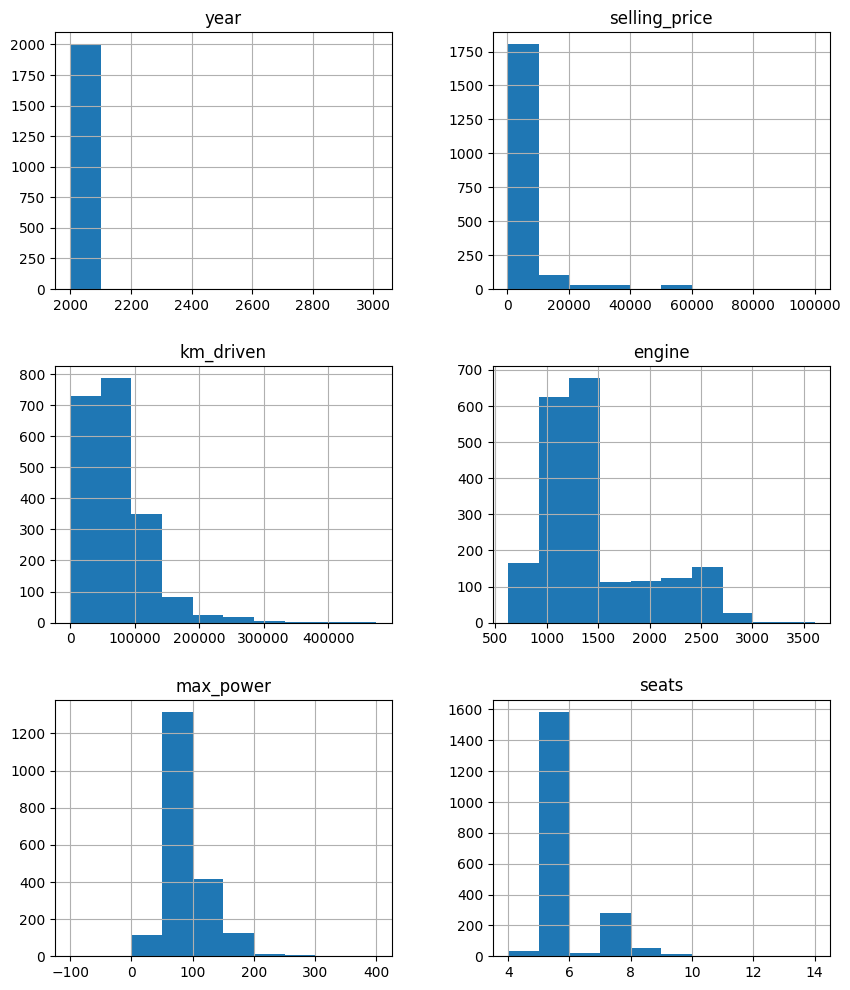

In [ ]:
df.hist(figsize=(10, 12))

sebagian besar datanya skew ke kiri

<Axes: >

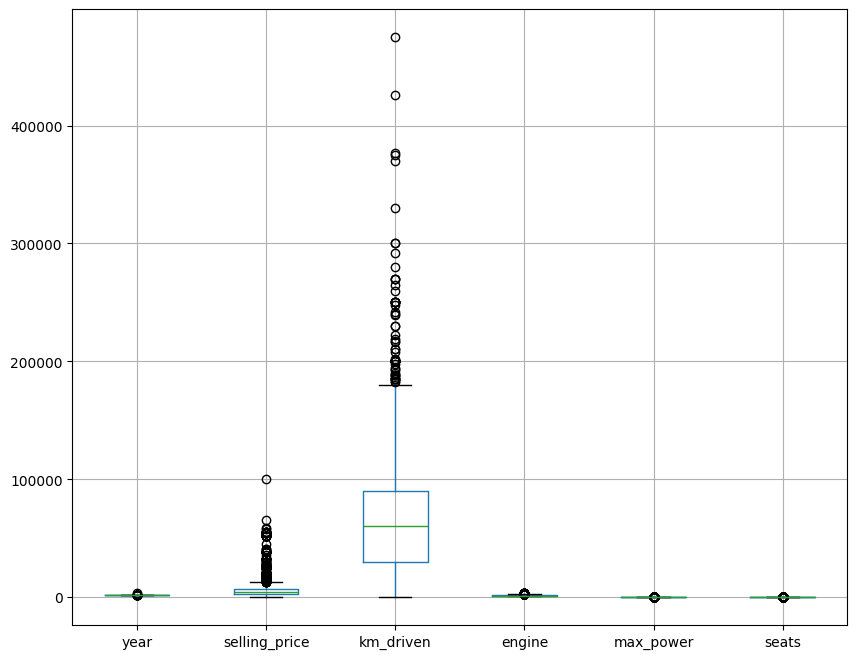

In [ ]:
df.boxplot(figsize=(10,8))

kolom `km_driven` dan `selling_price` terdapat banyak outlier value

In [ ]:
cat_cols = []
for col in df.columns:
    if df[col].dtype == 'object':
        cat_cols.append(col)
cat_cols

['Region',
 'State or Province',
 'City',
 'fuel',
 'seller_type',
 'transmission',
 'owner',
 'mileage',
 'torque',
 'sold']

In [ ]:
# cek inconsistent

for i in cat_cols:
    print(df[i].value_counts())
    print("\n")

Region
Central    605
West       507
East       483
South      403
N/A          2
Name: count, dtype: int64


State or Province
California              222
Texas                   135
New York                124
Illinois                119
Florida                 108
Michigan                 83
Washington               79
Ohio                     74
Pennsylvania             65
Indiana                  60
North Carolina           50
Georgia                  49
Virginia                 48
Massachusetts            47
New Jersey               44
Kansas                   42
Colorado                 40
Oregon                   38
Arizona                  36
Minnesota                35
Tennessee                33
Missouri                 30
Maryland                 30
Iowa                     29
Arkansas                 26
Idaho                    26
Wisconsin                26
Oklahoma                 24
Alabama                  22
Maine                    21
South Carolina           21
New 

dari pengecekan inconsistent, terdapat value N/A pada `region`, tidak ada nama variabel pada `transmission`

In [ ]:
num_cols = []
for col in df.columns:
    if col not in cat_cols:
        num_cols.append(col)
num_cols

['year', 'selling_price', 'km_driven', 'engine', 'max_power', 'seats']

In [ ]:
df['seats'].unique()

array([ 5,  7,  6,  4,  8,  9, 14, 10])

pada `seats` bentuknya lebih pengelompokkan sehingga data ini termasuk categorical data bukan numerical data.

In [ ]:
num_cols.remove('seats')
cat_cols.append('seats')
cat_cols

['Region',
 'State or Province',
 'City',
 'fuel',
 'seller_type',
 'transmission',
 'owner',
 'mileage',
 'torque',
 'sold',
 'seats']

In [ ]:
num_cols

['year', 'selling_price', 'km_driven', 'engine', 'max_power']

In [ ]:
df['year'].unique()

array([2013, 2004, 2017, 2016, 2019, 2015, 2007, 2018, 2014, 2011, 2012,
       2009, 2008, 2010, 2020, 2005, 2006, 2000, 2003, 1999, 2002, 3011])

# Splitting Data & Pre-Processing

Splitting data, dan melakukan pre-processing
1. memperbaiki tahun 3011 --> menjadi 2011
2. mengubah string kosong pada kolom transmission menjadi NaN
3. mengubah nilai negatif menjadi positif pada `max_power`
4. melakukan feature engineering --> mengekstraksi kolom teks torque menjadi 2 kolom numerik terpisah: torque_value dan rpm.

Semua fungsi ini akan diaplikasikan secara terpisah ke X_train, X_val, dan X_test.

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['selling_price'])
y = df['selling_price']

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=SEED_VALUE)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.125, random_state=SEED_VALUE)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

def clean_static_anomalies(df):
    df_clean = df.copy()

    df_clean['year'] = df_clean['year'].replace(3011, 2011)

    df_clean['transmission'] = df_clean['transmission'].replace(r'^\s*$ ', np.nan, regex=True)

    df_clean['max_power'] = df_clean['max_power'].abs()

    df_clean['torque_value'] = df_clean['torque'].str.extract(r'^([\d\.]+)').astype(float)
    df_clean['rpm'] = df_clean['torque'].str.extract(r'([\d,]{3,})').replace(',', '', regex=True).astype(float)

    df_clean = df_clean.drop('torque', axis=1)

    return df_clean

X_train_cleaned = clean_static_anomalies(X_train)
X_val_cleaned = clean_static_anomalies(X_val)
X_test_cleaned = clean_static_anomalies(X_test)

In [ ]:
X_train_cleaned.head()

,year,km_driven,Region,State or Province,City,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,sold,torque_value,rpm
777,2014,84784,South,Virginia,Portsmouth,Diesel,Dealer,Manual,First_Owner,24.0,1120,70.00,5,N,160.0,160.0
1804,2012,77000,West,Idaho,Eagle,Diesel,Individual,Manual,First_Owner,22.32,1582,126.32,5,N,259.8,259.0
1921,2019,40000,West,California,Los Angeles,Diesel,Individual,Automatic,First_Owner,23.8,1498,78.90,5,Y,160.0,160.0
1873,2009,52000,Central,Minnesota,Minneapolis,Petrol,Individual,Manual,Second_Owner,18.9,1061,67.00,5,N,84.0,3500.0
390,2016,23400,East,New York,Cohoes,Petrol,Individual,Manual,Second_Owner,23.95,998,67.10,5,N,90.0,3500.0


mengimputasi nilai missing value pada target menggunakan median yang dihitung manual dari y_train (median ini nanti digunakan untuk mengisi NaN pada y_train, y_val, maupun y_test). Hal ini dikarenakan `selling_price` merupakan variabel target, ia tidak boleh dimasukkan ke dalam pipeline feature transformer (karena hal ini dapat memicu data leakage)

In [ ]:
y_median = y_train.median()

y_train_imputed = y_train.fillna(y_median)
y_val_imputed = y_val.fillna(y_median)
y_test_imputed = y_test.fillna(y_median)

merancang pipeline, dan membuat pipeline untuk kolom numerik dan kategorikal.

Untuk numerik koloms, kita menggunakan SimpleImputer dengan strategi median, dilanjutkan scaling / normalisasi dengan StandardScaler.

Untuk categorical koloms, kita menggunakan SimpleImputer dengan strategi modus / most_frequent, diikuti OneHotEncoder untuk mengubah data teks menjadi format matriks numerik yang dapat diproses oleh ANN

In [ ]:
numeric_features = ['year', 'km_driven', 'engine', 'max_power', 'torque_value', 'rpm']

categorical_features = ['Region', 'State or Province', 'City', 'fuel',
                        'seller_type', 'transmission', 'owner', 'mileage',
                        'sold']
ord_features = ['seats']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
        ('ord', ordinal_transformer, ord_features)
    ])

agar model dapat belajar data kita menggunakan .fit_transform()

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train_cleaned)

X_val_processed = preprocessor.transform(X_val_cleaned)
X_test_processed = preprocessor.transform(X_test_cleaned)

input_dim = X_train_processed.shape[1]
min_neurons = input_dim * 2

### b. [LO1, LO2, LO3, & LO4 – 5 Points] Buatlah 1 baseline model. Semua hidden layer wajib menggunakan activation function bernama ReLU dan memiliki jumlah neuron minimal 2 kali lipat dari dimensi input data. Model anda harus memiliki minimal 2 hidden layer. Lakukan training pada model tersebut dengan minimal 20 epoch dan jelaskan hasilnya secara singkat.

# Modelling

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
baseline_model = Sequential()
baseline_model.add(Input(shape=(input_dim,)))
baseline_model.add(Dense(min_neurons, activation='relu'))
baseline_model.add(Dense(min_neurons, activation='relu'))
baseline_model.add(Dense(1, activation='linear'))

baseline_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

print("Training Baseline Model...")
history_base = baseline_model.fit(
    X_train_processed, y_train_imputed,
    validation_data=(X_val_processed, y_val_imputed),
    epochs=20,
    batch_size=32,
    verbose=1
)

model = tf.keras.Sequential(
    [
        Dense(12, activation="relu",input_shape=(43,)),
        Dense(4, activation="relu"),
        Dense(1, activation='linear'),
    ]
)

Training Baseline Model...
Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 7s 125ms/step - loss: 89297632.0000 - mae: 5444.8862 - val_loss: 89563064.0000 - val_mae: 3489.5388
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step - loss: 37295512.0000 - mae: 2876.4319 - val_loss: 48008224.0000 - val_mae: 3384.9495
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - loss: 21561226.0000 - mae: 2458.0405 - val_loss: 33507904.0000 - val_mae: 2824.5840
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 112ms/step - loss: 15242761.0000 - mae: 2232.8315 - val_loss: 24289638.0000 - val_mae: 2497.5879
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - loss: 11560260.0000 - mae: 1703.4645 - val_loss: 18817918.0000 - val_mae: 1978.1656
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step - loss: 8466987.0000 - mae: 1453.5916 - val_loss: 15285377.0000 - val_mae: 1771.1151
Epoch 7/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - loss: 6173654.5000 - mae: 1198.7937 - val_loss: 11090843.0000 - val_mae: 1582.7677
Epoch 8/20
4

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### c. [LO1, LO2, LO3, & LO4 – 5 Points] Lakukan modifikasi pada model anda. Anda dapat mengubah jumlah neuron dan layer ataupun activation function dari hidden layer. Anda juga dapat melakukan hyperparameter fine-tuning pada model anda. Lakukan training pada modifikasi model anda dan jelaskan alasan modifikasi yang anda lakukan.

In [ ]:
modified_model = Sequential()
modified_model.add(Dense(min_neurons * 4, input_dim=input_dim, activation='relu'))
modified_model.add(Dropout(0.2))
modified_model.add(Dense(min_neurons * 2, activation='relu'))
modified_model.add(Dropout(0.2))
modified_model.add(Dense(min_neurons, activation='relu'))
modified_model.add(Dense(1, activation='linear'))

custom_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
modified_model.compile(optimizer=custom_optimizer, loss='mse', metrics=['mae'])

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("Training Modified Model...")
history_mod = modified_model.fit(
    X_train_processed, y_train_imputed,
    validation_data=(X_val_processed, y_val_imputed),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Modified Model...
Epoch 1/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - loss: 40979580.0000 - mae: 3366.6042 - val_loss: 20221836.0000 - val_mae: 2648.1897
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - loss: 8541061.0000 - mae: 1729.6840 - val_loss: 10782675.0000 - val_mae: 1491.0983
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - loss: 2956071.7500 - mae: 1004.3591 - val_loss: 7413416.5000 - val_mae: 1313.1143
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - loss: 1327542.2500 - mae: 702.7991 - val_loss: 6629442.0000 - val_mae: 1216.0973
Epoch 5/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - loss: 1085354.0000 - mae: 669.3105 - val_loss: 6117676.0000 - val_mae: 1174.6903
Epoch 6/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - loss: 826427.2500 - mae: 567.5755 - val_loss: 5977431.5000 - val_mae: 1113.6160
Epoch 7/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - loss: 472244.3750 - mae: 437.0041 - val_loss: 5490951.0000 - val_mae: 1103.5220
Epoch 8/100
44/44 ━━━━━━━━━━━━━

### d. [LO2, LO3, & LO4 – 10 Points] Lakukan evaluasi pada 2 model yang sudah anda buat menggunakan minimal 3 evaluation metrics, lalu bandingkan, analisis, dan simpulkan hasilnya.  

In [ ]:
y_pred_base = baseline_model.predict(X_test_processed)
y_pred_mod = modified_model.predict(X_test_processed)

mse_base = mean_squared_error(y_test_imputed, y_pred_base)
rmse_base = np.sqrt(mse_base)
mae_base = mean_absolute_error(y_test_imputed, y_pred_base)
r2_base = r2_score(y_test_imputed, y_pred_base)

mse_mod = mean_squared_error(y_test_imputed, y_pred_mod)
rmse_mod = np.sqrt(mse_mod)
mae_mod = mean_absolute_error(y_test_imputed, y_pred_mod)
r2_mod = r2_score(y_test_imputed, y_pred_mod)

print("=== Evaluasi Baseline Model ===")
print("MSE  : ", mse_base)
print("RMSE : ", rmse_base)
print("MAE  : ", mae_base)
print("R2   : ", r2_base)

print("\n=== Evaluasi Modified Model ===")
print("MSE  : ", mse_mod)
print("RMSE : ", rmse_mod)
print("MAE  : ", mae_mod)
print("R2   : ", r2_mod)

# MAPE

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step
=== Evaluasi Baseline Model ===
MSE  :  4883559.1509925425
RMSE :  2209.877632583429
MAE  :  1220.1291288818359
R2   :  0.9399317350678345

=== Evaluasi Modified Model ===
MSE  :  3652433.203058496
RMSE :  1911.1340097069321
MAE  :  1080.286686380005
R2   :  0.9550747070927225


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

y_pred_base = baseline_model.predict(X_test_processed)
y_pred_mod = modified_model.predict(X_test_processed)

rmse_base = np.sqrt(mean_squared_error(y_test_imputed, y_pred_base))
mae_base = mean_absolute_error(y_test_imputed, y_pred_base)
mape_base = mean_absolute_percentage_error(y_test_imputed, y_pred_base)
r2_base = r2_score(y_test_imputed, y_pred_base)

rmse_mod = np.sqrt(mean_squared_error(y_test_imputed, y_pred_mod))
mae_mod = mean_absolute_error(y_test_imputed, y_pred_mod)
mape_mod = mean_absolute_percentage_error(y_test_imputed, y_pred_mod)
r2_mod = r2_score(y_test_imputed, y_pred_mod)

print("=== Evaluasi Baseline Model ===")
print("RMSE : ", rmse_base)
print("MAE  : ", mae_base)
print("MAPE : ", mape_base)
print("R2   : ", r2_base)

print("\n=== Evaluasi Modified Model ===")
print("RMSE : ", rmse_mod)
print("MAE  : ", mae_mod)
print("MAPE : ", mape_mod)
print("R2   : ", r2_mod)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 184ms/step
=== Evaluasi Baseline Model ===
RMSE :  2209.877632583429
MAE  :  1220.1291288818359
MAPE :  0.23043025980751572
R2   :  0.9399317350678345

=== Evaluasi Modified Model ===
RMSE :  1911.1340097069321
MAE  :  1080.286686380005
MAPE :  0.21424398824178945
R2   :  0.9550747070927225


Evaluasi menggunakan 4 metrik utama:
1. RMSE: melihat penalti terhadap error besar --> error semakin kecil
2. MAE: melihat rata-rata kesalahan absolut secara langsung
3. MAPE: melihat persentase penyimpangan prediksi terhadap harga asli
4. R2: melihat seberapa baik fitur menjelaskan variansi target. --> model lebih mampu menangkap pola dalam data

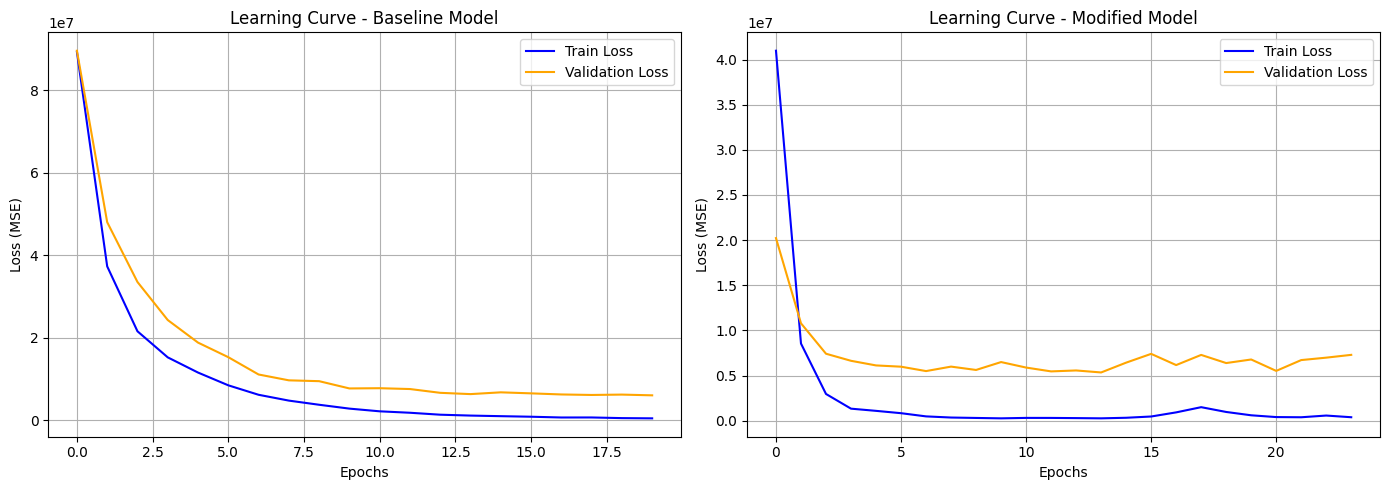

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_base.history['loss'], label='Train Loss', color='blue')
plt.plot(history_base.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Learning Curve - Baseline Model')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_mod.history['loss'], label='Train Loss', color='blue')
plt.plot(history_mod.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Learning Curve - Modified Model')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Model yang dimodifikasi lebih efisien (terlihat dari start loss yang lebih rendah), lebih stabil (validation loss lebih dekat ke train loss). Maka dapat kita simpulkan bahwa perubahan / modif modelnya berhasil meningkatkan performa.

tapi di satu sisi, gap antara train dan validation loss masih cukup besar dan mengindikasikan overfitting ringan.

Kurva tidak paralel --> (train loss jauh lebih rendah), tanda model terlalu fokus ke data latih.

Penyebab learning curve tersebut:
1. Data belum cukup bersih / normalisasi
2. Model terlalu kompleks
3. Jumlah epoch terbatas
4. Kurang regularisasi
5. Distribusi train/val tidak seimbang
6. masalah skala data

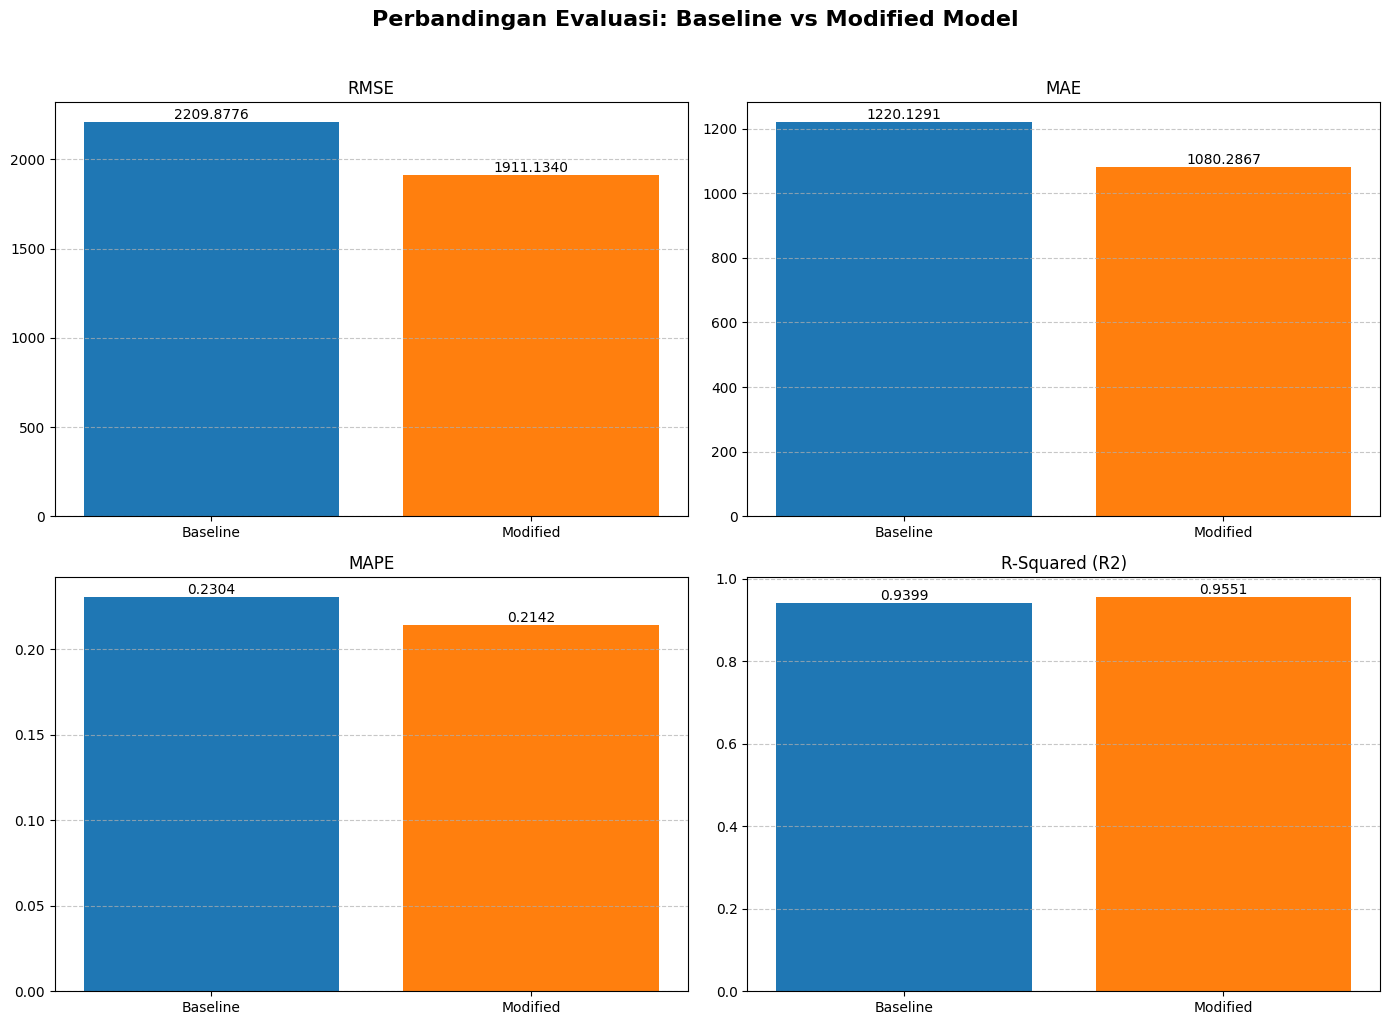

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Perbandingan Evaluasi: Baseline vs Modified Model', fontsize=16, fontweight='bold', y=1.02)

metrics = ['RMSE', 'MAE', 'MAPE', 'R-Squared (R2)']
base_vals = [rmse_base, mae_base, mape_base, r2_base]
mod_vals = [rmse_mod, mae_mod, mape_mod, r2_mod]

colors = ['#1f77b4', '#ff7f0e']

for i, ax in enumerate(axs.flatten()):
    bars = ax.bar(['Baseline', 'Modified'], [base_vals[i], mod_vals[i]], color=colors)
    ax.set_title(metrics[i], fontsize=12)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval, f"{yval:.4f}", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### Feature Importance

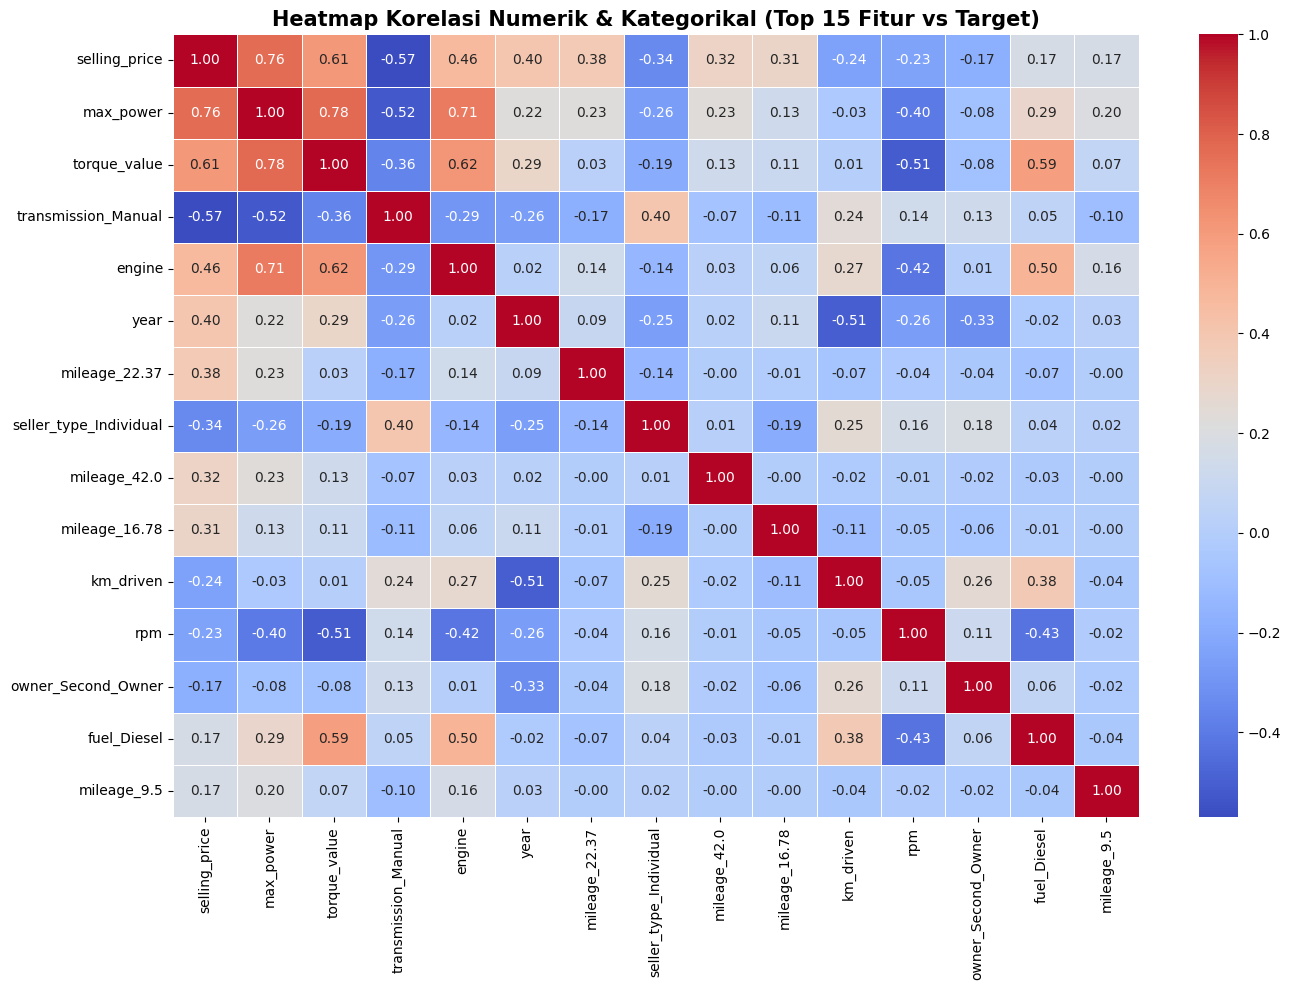

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

data_eda = X_train_cleaned.copy()
data_eda['selling_price'] = y_train_imputed

data_eda_encoded = pd.get_dummies(data_eda, drop_first=True)

correlation_matrix_full = data_eda_encoded.corr()

top_15_features = correlation_matrix_full['selling_price'].abs().sort_values(ascending=False).head(15).index

plt.figure(figsize=(14, 10))
sns.heatmap(
    data_eda_encoded[top_15_features].corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)
plt.title('Heatmap Korelasi Numerik & Kategorikal (Top 15 Fitur vs Target)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

dari plot heatmap diatas, dapat kita lihat bahwa `max_power`, `engine`, `year` merupakan prediktor utama harga.

sedangkan `km_driven`, `owner`, `transmission` termasuk kategori moderate / negative importance.